In [1]:
# Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load the dataset we created
df = pd.read_csv("../data/raw/grievances.csv")

# Shape = (rows, columns)
print("Shape:", df.shape)
# Head = first 5 rows
df.head()

Shape: (100, 3)


,complaint_text,department,sentiment
0,Auto drivers overcharging,Transport,Negative
1,Bumpy road causing accidents,Roads,Negative
2,Illegal dumping at park,Sanitation,Neutral
3,Road flooded during rain,Roads,Negative
4,Speed breaker needed near school,Roads,Neutral


In [2]:
# Basic Stats

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check data types
print("\nData types:\n", df.dtypes)

# Department distribution
print("\nDepartment counts:\n", df['department'].value_counts())

# Sentiment distribution
print("\nSentiment counts:\n", df['sentiment'].value_counts())

# Add complaint text length column
df['text_length'] = df['complaint_text'].apply(len)

print("\nAverage complaint length (chars):",
      round(df['text_length'].mean(), 1))

Missing values:
 complaint_text    0
department        0
sentiment         0
dtype: int64

Data types:
 complaint_text    str
department        str
sentiment         str
dtype: object

Department counts:
 department
Transport      20
Roads          20
Sanitation     20
Electricity    20
Water          20
Name: count, dtype: int64

Sentiment counts:
 sentiment
Negative           56
Neutral            25
Urgent/Critical    19
Name: count, dtype: int64

Average complaint length (chars): 29.5


C:\Users\Ashmita Mallick\AppData\Local\Temp\ipykernel_23356\1131510867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='department', palette='viridis')


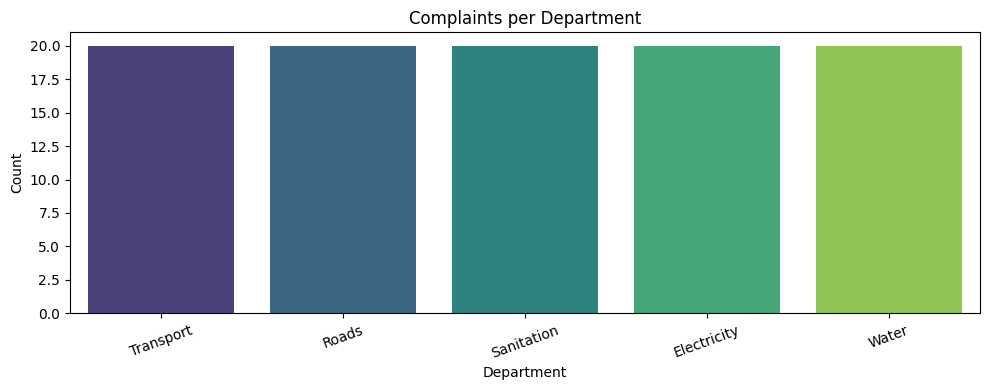

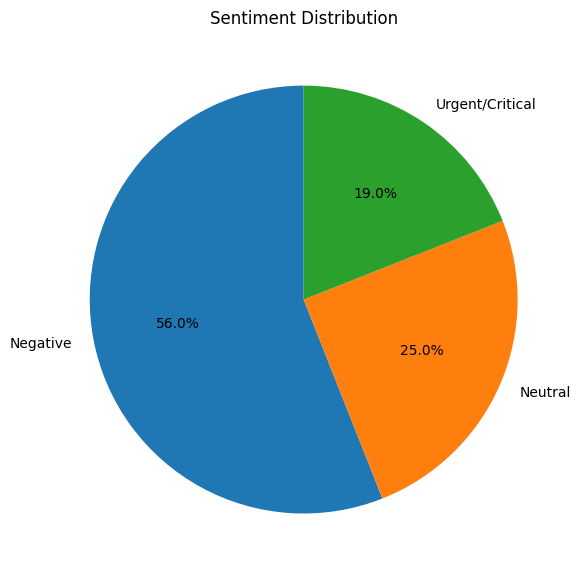

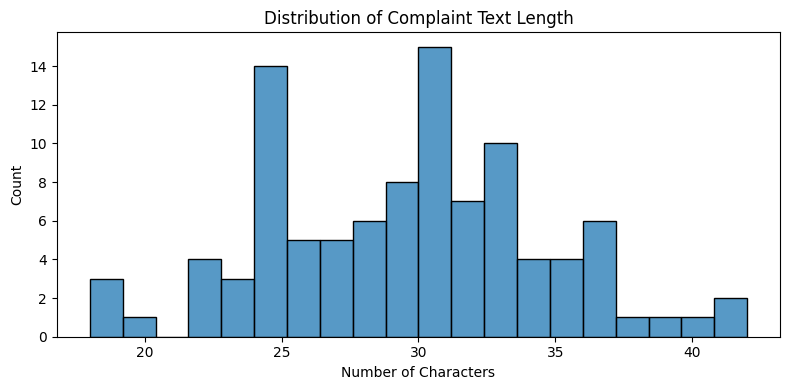

In [3]:
# Charts

import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Department distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='department', palette='viridis')

plt.title('Complaints per Department')
plt.xlabel('Department')
plt.ylabel('Count')

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("../data/processed/dept_distribution.png")
plt.show()


# Chart 2: Sentiment distribution
plt.figure(figsize=(6, 6))

df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sentiment Distribution')
plt.ylabel('')

plt.tight_layout()

plt.savefig("../data/processed/sentiment_dist.png")
plt.show()


# Chart 3: Complaint text length
plt.figure(figsize=(8, 4))

sns.histplot(df['text_length'], bins=20)

plt.title('Distribution of Complaint Text Length')
plt.xlabel('Number of Characters')

plt.tight_layout()

plt.savefig("../data/processed/text_length.png")
plt.show()

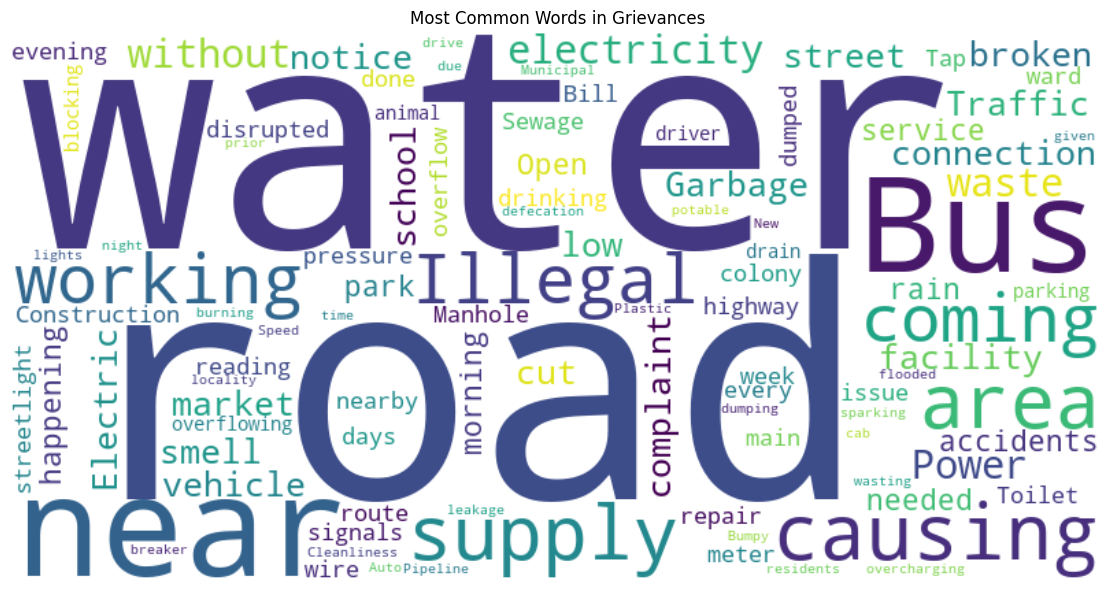

C:\Users\Ashmita Mallick\AppData\Local\Temp\ipykernel_23356\408648589.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


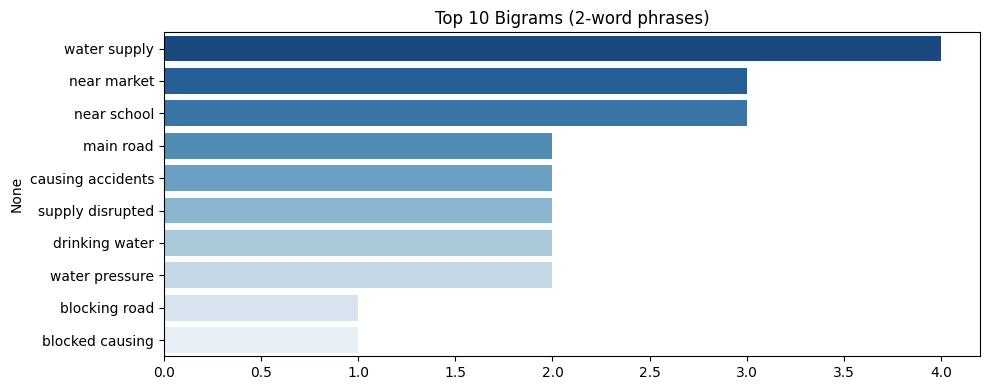

In [ ]:
# Word Cloud and Bigram Analysis

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Word cloud
all_text = ' '.join(df['complaint_text'].values)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=100
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title('Most Common Words in Grievances')

plt.tight_layout()

plt.savefig("../data/processed/wordcloud.png")
plt.show()


# Bigram analysis
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['complaint_text'])

bigrams = pd.Series(
    X.toarray().sum(axis=0),
    index=vectorizer.get_feature_names_out()
)

top_bigrams = bigrams.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))

sns.barplot(
    x=top_bigrams.values,
    y=top_bigrams.index,
    palette='Blues_r'
)

plt.title('Top 10 Bigrams (2-word phrases)')

plt.tight_layout()

plt.savefig("../data/processed/bigrams.png")
plt.show()  